In [1]:
import requests
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [23]:
#Task1
latitude = 12.9716
longitude = 77.5946

url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    f"&hourly=temperature_2m,"
    f"relative_humidity_2m,"
    f"surface_pressure,"
    f"wind_speed_10m"
    f"&forecast_days=7"
)

response = requests.get(url)

print("Status Code:", response.status_code)

weather = response.json()

Status Code: 200


In [24]:
#Task1
hourly = weather["hourly"]

df = pd.DataFrame({
    "Time": hourly["time"],
    "Temperature": hourly["temperature_2m"],
    "Humidity": hourly["relative_humidity_2m"],
    "Pressure": hourly["surface_pressure"],
    "WindSpeed": hourly["wind_speed_10m"]
})

df.head()

,Time,Temperature,Humidity,Pressure,WindSpeed
0,2026-07-27T00:00,21.4,89,908.9,17.4
1,2026-07-27T01:00,21.5,89,909.3,17.4
2,2026-07-27T02:00,22.5,84,909.8,16.3
3,2026-07-27T03:00,23.8,75,910.3,20.8
4,2026-07-27T04:00,25.4,65,910.9,23.0


In [25]:
#Task1
print("First Five Records:\n")

df.head()

First Five Records:



,Time,Temperature,Humidity,Pressure,WindSpeed
0,2026-07-27T00:00,21.4,89,908.9,17.4
1,2026-07-27T01:00,21.5,89,909.3,17.4
2,2026-07-27T02:00,22.5,84,909.8,16.3
3,2026-07-27T03:00,23.8,75,910.3,20.8
4,2026-07-27T04:00,25.4,65,910.9,23.0


In [26]:
#Task1
df["Weather_Class"] = np.where(
    df["Temperature"] >= 25,
    "Warm",
    "Cool"
)

df.head()

,Time,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,2026-07-27T00:00,21.4,89,908.9,17.4,Cool
1,2026-07-27T01:00,21.5,89,909.3,17.4,Cool
2,2026-07-27T02:00,22.5,84,909.8,16.3,Cool
3,2026-07-27T03:00,23.8,75,910.3,20.8,Cool
4,2026-07-27T04:00,25.4,65,910.9,23.0,Warm


In [27]:
#Task1
input_features = [
    "Temperature",
    "Relative_Humidity",
    "Surface_Pressure",
    "Wind_Speed"
]

target_variable = "Weather_Class"

print("Input Features:")
print(input_features)

print("\nTarget Variable:")
print(target_variable)

Input Features:
['Temperature', 'Relative_Humidity', 'Surface_Pressure', 'Wind_Speed']

Target Variable:
Weather_Class


In [28]:
#Task1
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst Five Rows:")
display(df.head())

Dataset Shape: (168, 6)

Column Names:
Index(['Time', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed',
       'Weather_Class'],
      dtype='object')

First Five Rows:


,Time,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,2026-07-27T00:00,21.4,89,908.9,17.4,Cool
1,2026-07-27T01:00,21.5,89,909.3,17.4,Cool
2,2026-07-27T02:00,22.5,84,909.8,16.3,Cool
3,2026-07-27T03:00,23.8,75,910.3,20.8,Cool
4,2026-07-27T04:00,25.4,65,910.9,23.0,Warm


In [29]:
#Task2
# Check for missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Time             0
Temperature      0
Humidity         0
Pressure         0
WindSpeed        0
Weather_Class    0
dtype: int64


In [30]:
#Task2
# Remove unnecessary column
df = df.drop(columns=["Time"])

print(df.head())

   Temperature  Humidity  Pressure  WindSpeed Weather_Class
0         21.4        89     908.9       17.4          Cool
1         21.5        89     909.3       17.4          Cool
2         22.5        84     909.8       16.3          Cool
3         23.8        75     910.3       20.8          Cool
4         25.4        65     910.9       23.0          Warm


In [31]:
#Task2
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Weather_Class"] = encoder.fit_transform(df["Weather_Class"])

print("Encoding Mapping:")

for label, value in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"{label} -> {value}")

Encoding Mapping:
Cool -> 0
Warm -> 1


In [32]:
#Task2
X = df.drop("Weather_Class", axis=1)

y = df["Weather_Class"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (168, 4)
Target Shape   : (168,)


In [33]:
#Task2
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (134, 4)
Testing Data  : (34, 4)


In [34]:
#Task2
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [35]:
#Task2
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

scaled_df.head()

,Temperature,Humidity,Pressure,WindSpeed
0,-0.935398,1.075435,0.595927,-1.147790
1,-1.048015,1.151642,0.109435,-1.459071
2,-0.935398,1.075435,0.109435,-0.587485
3,-0.071997,0.313360,-0.099062,-0.836509
4,-0.710163,0.618190,-1.280542,-0.058307


In [36]:
#Task3
# Create the SVM classifier
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

print(svm_model)

SVC(random_state=42)


In [37]:
#Task3
svm_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [38]:
#Task3
# Predict on the test dataset
y_pred = svm_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:10])

Predictions:
[0 0 0 0 1 1 1 0 0 0]


In [39]:
#Task3
results = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred)
})

results.head(10)

,Actual,Predicted
0,Cool,Cool
1,Cool,Cool
2,Cool,Cool
3,Cool,Cool
4,Warm,Warm
5,Warm,Warm
6,Warm,Warm
7,Cool,Cool
8,Cool,Cool
9,Cool,Cool


In [41]:
#Task4
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")

Accuracy Score : 0.9706
Precision      : 1.0000
Recall         : 0.9167
F1-Score       : 0.9565


In [42]:
#Task4
print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

Classification Report:

              precision    recall  f1-score   support

        Cool       0.96      1.00      0.98        22
        Warm       1.00      0.92      0.96        12

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34



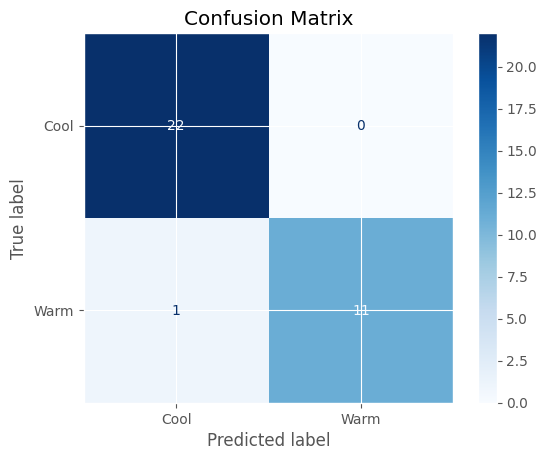

In [43]:
#Task4
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# Task 4
# Observations
1. The SVM classifier achieved an accuracy of 97.06%, indicating excellent performance in classifying weather conditions. Out of 34 test samples, only one sample was misclassified.
2. The model achieved a precision of 100%, which means every instance predicted as "Warm" was actually warm. This indicates that the classifier produced no false positive predictions for the Warm class.
3. The recall of 91.67% and F1-score of 95.65% demonstrate that the model correctly identified most Warm weather instances while maintaining a strong balance between precision and recall. The confusion matrix shows only one Warm sample was incorrectly classified as Cool, confirming the effectiveness of the RBF kernel for this classification task.

# Conclusion
This assignment successfully implemented a Support Vector Machine (SVM) classifier to classify weather conditions as Warm or Cool using temperature, relative humidity, surface pressure, and wind speed obtained from the Open-Meteo API. The trained model achieved an accuracy of 97.06%, demonstrating excellent classification performance with only one misclassified test sample. Feature scaling using StandardScaler was essential because SVM relies on distance-based calculations, and scaling ensures that all features contribute equally to the decision boundary. One major advantage of the SVM algorithm is its ability to achieve high accuracy and effectively handle nonlinear classification problems using the RBF kernel. However, a limitation of SVM is that its training time and computational cost increase significantly for large datasets, making it less suitable for very large-scale classification tasks.